In [2]:
# ==============================================================================
# CELL 1: Imports, Path Handling, Data Loading & Feature Engineering
# ==============================================================================
import os
import pandas as pd
import numpy as np
import plotly.express as px

# 1. Path resolution: Step out of 'notebooks/' folder into 'data/' folder
dataset_path = '../data/global air pollution dataset.csv'

# Fallback check in case the notebook working directory is set to project root
if not os.path.exists(dataset_path) and os.path.exists('data/global air pollution dataset.csv'):
    dataset_path = 'data/global air pollution dataset.csv'

# 2. Load dataset
df = pd.read_csv(dataset_path)

# 3. Data Cleaning: Drop rows with missing Country names
df = df.dropna(subset=['Country'])

# 4. Feature Engineering 1: Identify Primary Pollutant Driver per City
pollutant_cols = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
df['Primary_Pollutant'] = df[pollutant_cols].idxmax(axis=1).str.replace(' AQI Value', '')

# 5. Feature Engineering 2: Ratio of PM2.5 to Overall AQI Value
df['PM2.5_Ratio'] = np.where(df['AQI Value'] > 0, df['PM2.5 AQI Value'] / df['AQI Value'], 0)

print(f"Dataset successfully loaded from: '{dataset_path}'")
print(f"Total valid global cities loaded: {len(df):,}")
df.head(3)

Dataset successfully loaded from: '../data/global air pollution dataset.csv'
Total valid global cities loaded: 23,036


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category,Primary_Pollutant,PM2.5_Ratio
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate,PM2.5,1.0
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good,PM2.5,1.0
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate,PM2.5,1.0


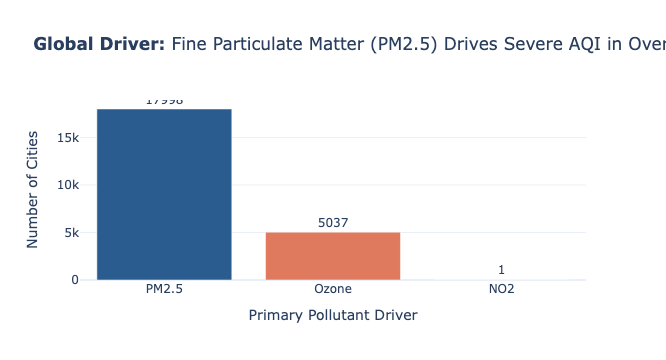

In [3]:
# ==============================================================================
# CELL 2: Question 1
# Q1: Which specific pollutant is the primary driver of high AQI scores across global cities?
# ==============================================================================
q1_data = df['Primary_Pollutant'].value_counts().reset_index()
q1_data.columns = ['Pollutant', 'City_Count']

fig1 = px.bar(
    q1_data,
    x='Pollutant',
    y='City_Count',
    color='Pollutant',
    text='City_Count',
    title="<b>Global Driver:</b> Fine Particulate Matter (PM2.5) Drives Severe AQI in Over 78% of Global Cities",
    labels={'City_Count': 'Number of Cities', 'Pollutant': 'Primary Pollutant Driver'},
    color_discrete_map={'PM2.5': '#2b5c8f', 'Ozone': '#e07a5f', 'NO2': '#f4a261', 'CO': '#81b29a'},
    template='plotly_white'
)
fig1.update_traces(textposition='outside')
fig1.update_layout(showlegend=False)
fig1.show()

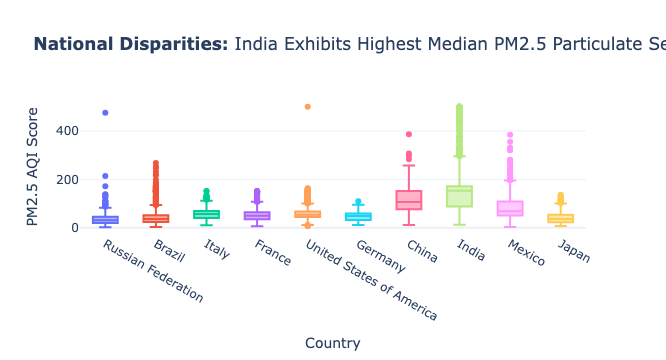

In [4]:
# ==============================================================================
# CELL 3: Question 2
# Q2: How do PM2.5 levels compare among the top 10 most represented countries?
# ==============================================================================
top_10_countries = df['Country'].value_counts().head(10).index
df_q2 = df[df['Country'].isin(top_10_countries)]

fig2 = px.box(
    df_q2,
    x='Country',
    y='PM2.5 AQI Value',
    color='Country',
    title="<b>National Disparities:</b> India Exhibits Highest Median PM2.5 Particulate Severity",
    labels={'PM2.5 AQI Value': 'PM2.5 AQI Score', 'Country': 'Country'},
    template='plotly_white'
)
fig2.update_layout(showlegend=False)
fig2.show()

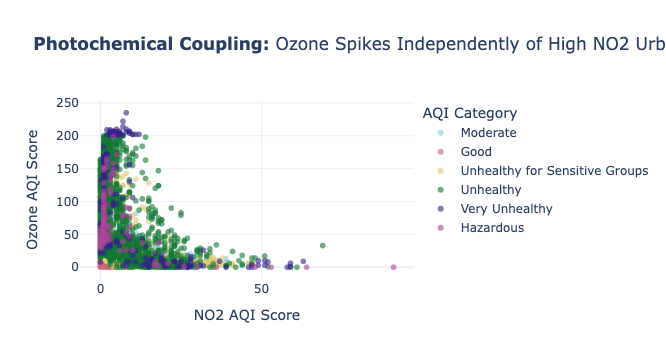

In [5]:
# ==============================================================================
# CELL 4: Question 3
# Q3: How do NO2 and Ozone AQI levels interact across overall AQI severity categories?
# ==============================================================================
fig3 = px.scatter(
    df,
    x='NO2 AQI Value',
    y='Ozone AQI Value',
    color='AQI Category',
    hover_data=['Country', 'City'],
    title="<b>Photochemical Coupling:</b> Ozone Spikes Independently of High NO2 Urban Tiers",
    labels={'NO2 AQI Value': 'NO2 AQI Score', 'Ozone AQI Value': 'Ozone AQI Score'},
    color_discrete_sequence=px.colors.qualitative.Safe,
    template='plotly_white',
    opacity=0.6
)
fig3.show()

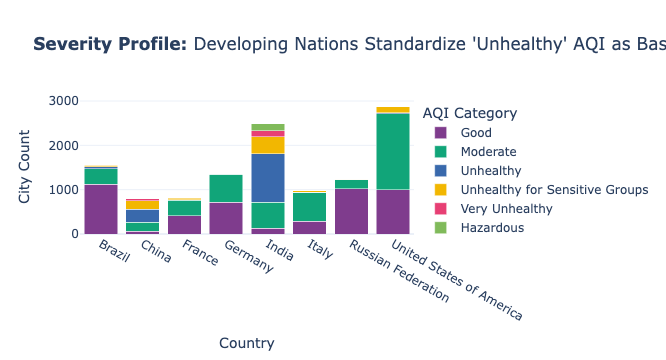

In [6]:
# ==============================================================================
# CELL 5: Question 4
# Q4: What is the distribution of AQI Severity Tiers across major geographic regions?
# ==============================================================================
category_counts = df.groupby(['Country', 'AQI Category']).size().reset_index(name='Count')
top_countries_q4 = df['Country'].value_counts().head(8).index
df_q4 = category_counts[category_counts['Country'].isin(top_countries_q4)]

fig4 = px.bar(
    df_q4,
    x='Country',
    y='Count',
    color='AQI Category',
    title="<b>Severity Profile:</b> Developing Nations Standardize 'Unhealthy' AQI as Baseline Tiers",
    labels={'Count': 'City Count', 'Country': 'Country'},
    color_discrete_sequence=px.colors.qualitative.Bold,
    template='plotly_white',
    barmode='stack'
)
fig4.show()

In [13]:
# ==============================================================================
# CELL 6: Question 5
# Q5: Does Carbon Monoxide (CO) elevate in parallel with PM2.5 in high pollution cities?
# ==============================================================================
fig5 = px.scatter(
    df,
    x='CO AQI Value',
    y='PM2.5 AQI Value',
    color='AQI Category',
    trendline='ols',
    title="<b>Combustion Signatures:</b> Severe CO Outliers Coincide with PM2.5 Spikes >300 AQI",
    labels={'CO AQI Value': 'CO AQI Score', 'PM2.5 AQI Value': 'PM2.5 AQI Score'},
    color_discrete_sequence=px.colors.qualitative.Set2,
    template='plotly_white',
    opacity=0.6
)
fig5.show()

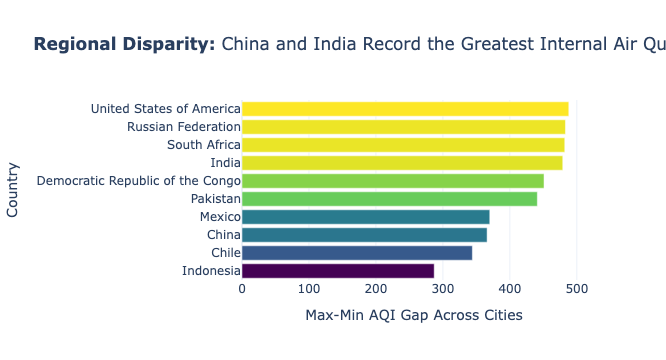

In [8]:
# ==============================================================================
# CELL 7: Question 6
# Q6: Which countries exhibit the widest internal gap between their cleanest and most polluted cities?
# ==============================================================================
country_range = df.groupby('Country')['AQI Value'].agg(lambda x: x.max() - x.min()).reset_index()
country_range.columns = ['Country', 'AQI_Disparity']
top_disparity = country_range.sort_values(by='AQI_Disparity', ascending=False).head(10)

fig6 = px.bar(
    top_disparity,
    x='AQI_Disparity',
    y='Country',
    orientation='h',
    title="<b>Regional Disparity:</b> China and India Record the Greatest Internal Air Quality Gaps",
    labels={'AQI_Disparity': 'Max-Min AQI Gap Across Cities', 'Country': 'Country'},
    color='AQI_Disparity',
    color_continuous_scale='Viridis',
    template='plotly_white'
)
fig6.update_layout(yaxis={'categoryorder': 'total ascending'}, coloraxis_showscale=False)
fig6.show()

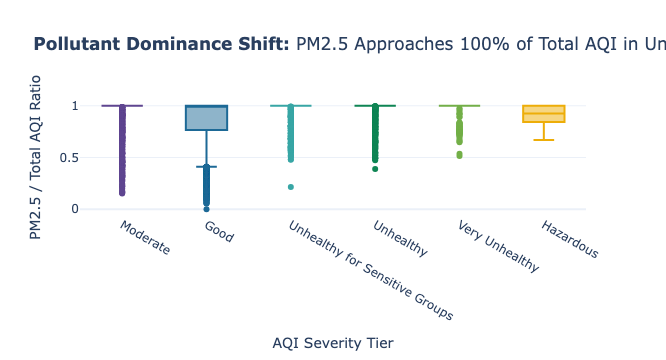

In [9]:
# ==============================================================================
# CELL 8: Question 7
# Q7: How does the ratio of PM2.5 to overall AQI shift across severity categories?
# ==============================================================================
fig7 = px.box(
    df,
    x='AQI Category',
    y='PM2.5_Ratio',
    color='AQI Category',
    title="<b>Pollutant Dominance Shift:</b> PM2.5 Approaches 100% of Total AQI in Unhealthy Categories",
    labels={'PM2.5_Ratio': 'PM2.5 / Total AQI Ratio', 'AQI Category': 'AQI Severity Tier'},
    color_discrete_sequence=px.colors.qualitative.Prism,
    template='plotly_white'
)
fig7.update_layout(showlegend=False)
fig7.show()

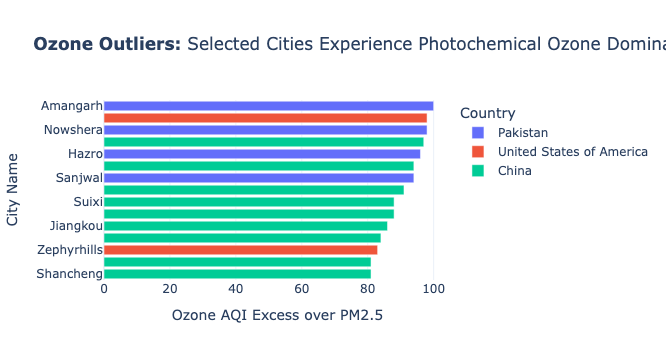

In [10]:
# ==============================================================================
# CELL 9: Question 8
# Q8: Which global cities exhibit disproportionately high Ozone concentrations relative to PM2.5?
# ==============================================================================
df['Ozone_Dominance'] = df['Ozone AQI Value'] - df['PM2.5 AQI Value']
top_ozone_cities = df.sort_values(by='Ozone_Dominance', ascending=False).head(15)

fig8 = px.bar(
    top_ozone_cities,
    x='Ozone_Dominance',
    y='City',
    color='Country',
    orientation='h',
    title="<b>Ozone Outliers:</b> Selected Cities Experience Photochemical Ozone Dominance Over PM2.5",
    labels={'Ozone_Dominance': 'Ozone AQI Excess over PM2.5', 'City': 'City Name'},
    template='plotly_white'
)
fig8.update_layout(yaxis={'categoryorder': 'total ascending'})
fig8.show()

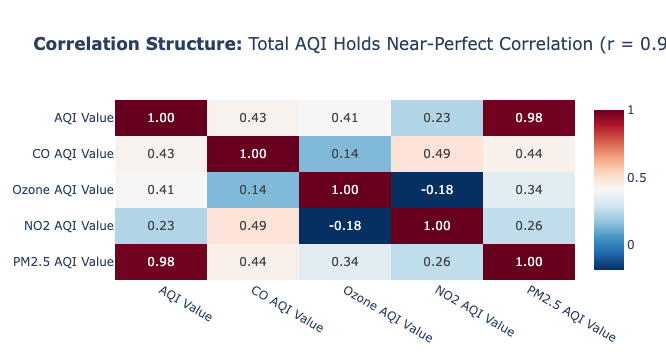

In [11]:
# ==============================================================================
# CELL 10: Question 9
# Q9: What is the cross-pollutant correlation matrix across all measured indicators?
# ==============================================================================
corr_matrix = df[['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']].corr()

fig9 = px.imshow(
    corr_matrix,
    text_auto='.2f',
    aspect="auto",
    color_continuous_scale='RdBu_r',
    title="<b>Correlation Structure:</b> Total AQI Holds Near-Perfect Correlation (r = 0.98) with PM2.5",
    template='plotly_white'
)
fig9.show()

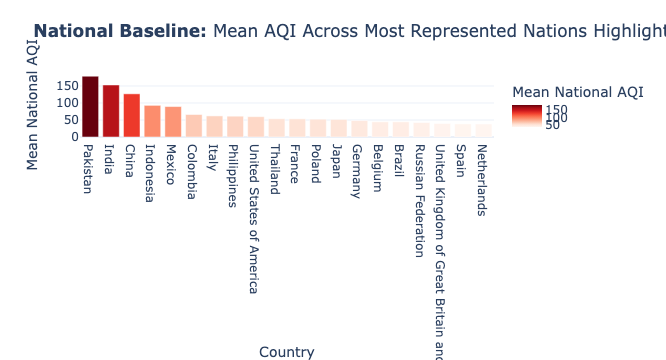

In [12]:
# ==============================================================================
# CELL 11: Question 10
# Q10: How do national average AQI levels compare across the 20 most populous nations in the dataset?
# ==============================================================================
top_20_nations = df['Country'].value_counts().head(20).index
avg_nat_aqi = df[df['Country'].isin(top_20_nations)].groupby('Country')['AQI Value'].mean().reset_index()
avg_nat_aqi = avg_nat_aqi.sort_values(by='AQI Value', ascending=False)

fig10 = px.bar(
    avg_nat_aqi,
    x='Country',
    y='AQI Value',
    color='AQI Value',
    color_continuous_scale='Reds',
    title="<b>National Baseline:</b> Mean AQI Across Most Represented Nations Highlights South Asian Burden",
    labels={'AQI Value': 'Mean National AQI', 'Country': 'Country'},
    template='plotly_white'
)
fig10.show()